# MongoDB Semester Project - Data Analysis and Preparation
## Topic: Hospital data
### [Dataset  source](https://www.kaggle.com/datasets/rajkumarpadmanabhan/ca-hospital-dataset-q1-2025)
### Selected file: patients, encounters, claims and billing


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

In [3]:
DATA_DIR = Path(".")

patients_path = DATA_DIR / "patients.csv"
encounters_path = DATA_DIR / "encounters.csv"
claims_path = DATA_DIR / "claims_and_billing.csv"

# basic check
print("patients exists:", patients_path.exists(), patients_path)
print("encounters exists:", encounters_path.exists(), encounters_path)
print("claims exists:", claims_path.exists(), claims_path)

patients exists: True patients.csv
encounters exists: True encounters.csv
claims exists: True claims_and_billing.csv


In [ ]:
# Input files load
patients = pd.read_csv(patients_path, low_memory=False)
encounters = pd.read_csv(encounters_path, low_memory=False)
claims = pd.read_csv(claims_path, low_memory=False)

print("Input files loaded successfully.")

Input files loaded successfully.


In [ ]:
# Overview of columns and first few rows
for name, file in {
    "patients": patients,
    "encounters": encounters,
    "claims_and_billing": claims
}.items():
    print("=" * 80)
    print(f"{name.upper()}")
    print(F"- Columns ({file.columns.size}):")
    print(file.columns.tolist())
    print("- First 5 rows:")
    display(file.head())

PATIENTS
- Columns (16):
['patient_id', 'first_name', 'last_name', 'dob', 'age', 'gender', 'ethnicity', 'insurance_type', 'marital_status', 'address', 'city', 'state', 'zip', 'phone', 'email', 'registration_date']
- First 5 rows:


,patient_id,first_name,last_name,dob,age,gender,ethnicity,insurance_type,marital_status,address,city,state,zip,phone,email,registration_date
0,PAT000001,Danielle,Johnson,14-05-1940,85,Female,Asian,UHC,Married,32181 Johnson Course Apt. 389,Bakersfield,CA,93301.0,NaN,danielle.johnson40@example.com,03-01-2025
1,PAT000002,Anna,Baldwin,04-03-2010,15,Female,White,Aetna,Married,79402 Peterson Drives Apt. 511,Bakersfield,CA,93301.0,(615)759 407,anna.baldwin294@example.com,26-02-2025
2,PAT000003,James,Jones,31-03-2021,4,Male,White,UHC,Married,1316 Chavez Village,Portland,OR,97035.0,(925)853 419,james.jones377@example.com,27-01-2025
3,PAT000004,Veronica,Bowman,26-08-1976,48,Female,Hispanic,BCBS,Widowed/Divorced/Separated,503 Linda Locks,Seattle,WA,98101.0,NaN,veronica.bowman653@example.com,26-01-2025
4,PAT000005,Carl,Gentry,06-01-1942,83,Male,Hispanic,BCBS,Married,NaN,NaN,NaN,NaN,001 553 676,carl.gentry91@example.com,14-03-2025


ENCOUNTERS
- Columns (13):
['encounter_id', 'patient_id', 'provider_id', 'visit_date', 'visit_type', 'department', 'reason_for_visit', 'diagnosis_code', 'admission_type', 'discharge_date', 'length_of_stay', 'status', 'readmitted_flag']
- First 5 rows:


,encounter_id,patient_id,provider_id,visit_date,visit_type,department,reason_for_visit,diagnosis_code,admission_type,discharge_date,length_of_stay,status,readmitted_flag
0,ENC017535,PAT000001,PRO00865,03-01-2025,Outpatient,Obstetrics & Gynecology,Irregular Menstruation,N92.6,NaN,NaN,NaN,Completed,Yes
1,ENC030367,PAT000001,PRO00579,30-03-2025,Telehealth,Gastroenterology,IBS,K58.9,NaN,NaN,NaN,Completed,Yes
2,ENC038533,PAT000002,PRO01227,26-02-2025,Inpatients,Dermatology,Acne,L70.9,NaN,01-03-2025,3.0,Completed,No
3,ENC056041,PAT000003,PRO00055,27-01-2025,Emergency,Emergency Department,Accidental Injury,S09.90XA,Emergency,NaN,NaN,Completed,No
4,ENC046849,PAT000004,PRO00043,26-01-2025,Emergency,Emergency Department,Accidental Injury,S09.90XA,Emergency,NaN,NaN,Completed,No


CLAIMS_AND_BILLING
- Columns (11):
['billing_id', 'patient_id', 'encounter_id', 'insurance_provider', 'payment_method', 'claim_id', 'claim_billing_date', 'billed_amount', 'paid_amount', 'claim_status', 'denial_reason']
- First 5 rows:


,billing_id,patient_id,encounter_id,insurance_provider,payment_method,claim_id,claim_billing_date,billed_amount,paid_amount,claim_status,denial_reason
0,BILL000001,PAT001464,ENC000001,BCBS,Insurance,CLM000001,06-02-2025 00:00,1971.52,0.00,Denied,Claim Billed to Wrong Payer
1,BILL000002,PAT025832,ENC000002,Medicare,Insurance,CLM000002,01-05-2025 00:00,1243.80,736.05,Paid,NaN
2,BILL000003,PAT055873,ENC000003,BCBS,Insurance,CLM000003,23-02-2025 00:00,4854.11,2676.12,Paid,NaN
3,BILL000004,PAT048558,ENC000004,BCBS,Insurance,CLM000004,20-04-2025 00:00,2638.21,1861.39,Paid,NaN
4,BILL000005,PAT018366,ENC000005,BCBS,Selfpay,NaN,NaN,1046.99,1046.99,Paid,NaN


In [ ]:
# Row and column counts
summary_counts = pd.DataFrame({
    "dataset": ["patients", "encounters", "claims_and_billing"],
    "rows": [len(patients), len(encounters), len(claims)],
    "columns": [patients.shape[1], encounters.shape[1], claims.shape[1]]
})

display(summary_counts)

,dataset,rows,columns
0,patients,60000,16
1,encounters,70000,13
2,claims_and_billing,70000,11



At least one dataset has 5,000+ rows: True


In [ ]:
# Initial datatypes
print("PATIENTS INFO")
print(patients.info())

print("\nENCOUNTERS INFO")
print(encounters.info())

print("\nCLAIMS INFO")
print(claims.info())

PATIENTS INFO
<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         60000 non-null  str    
 1   first_name         60000 non-null  str    
 2   last_name          60000 non-null  str    
 3   dob                60000 non-null  str    
 4   age                60000 non-null  int64  
 5   gender             60000 non-null  str    
 6   ethnicity          60000 non-null  str    
 7   insurance_type     60000 non-null  str    
 8   marital_status     60000 non-null  str    
 9   address            54063 non-null  str    
 10  city               54063 non-null  str    
 11  state              54063 non-null  str    
 12  zip                54063 non-null  float64
 13  phone              53996 non-null  str    
 14  email              47962 non-null  str    
 15  registration_date  60000 non-null  str    
dtypes: float64(1), int6

In [13]:
def missing_summary(df, name):
    out = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values
    }).sort_values("missing_pct", ascending=False)
    out["dataset"] = name
    return out

missing_patients = missing_summary(patients, "patients")
missing_encounters = missing_summary(encounters, "encounters")
missing_claims = missing_summary(claims, "claims_and_billing")

display(missing_patients)
display(missing_encounters)
display(missing_claims)

,column,missing_count,missing_pct,dataset
14,email,12038,20.06,patients
13,phone,6004,10.01,patients
10,city,5937,9.90,patients
9,address,5937,9.90,patients
11,state,5937,9.90,patients
12,zip,5937,9.90,patients
0,patient_id,0,0.00,patients
1,first_name,0,0.00,patients
7,insurance_type,0,0.00,patients
6,ethnicity,0,0.00,patients


,column,missing_count,missing_pct,dataset
8,admission_type,48406,69.15,encounters
9,discharge_date,45655,65.22,encounters
10,length_of_stay,45655,65.22,encounters
1,patient_id,0,0.00,encounters
0,encounter_id,0,0.00,encounters
4,visit_type,0,0.00,encounters
3,visit_date,0,0.00,encounters
2,provider_id,0,0.00,encounters
5,department,0,0.00,encounters
7,diagnosis_code,0,0.00,encounters


,column,missing_count,missing_pct,dataset
10,denial_reason,64002,91.43,claims_and_billing
6,claim_billing_date,10362,14.80,claims_and_billing
5,claim_id,10362,14.80,claims_and_billing
2,encounter_id,0,0.00,claims_and_billing
1,patient_id,0,0.00,claims_and_billing
0,billing_id,0,0.00,claims_and_billing
4,payment_method,0,0.00,claims_and_billing
3,insurance_provider,0,0.00,claims_and_billing
7,billed_amount,0,0.00,claims_and_billing
8,paid_amount,0,0.00,claims_and_billing


/var/folders/qs/d8f7sd3x6gl1p_s9hz43snjh0000gn/T/ipykernel_72400/3092849505.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_missing, x="missing_pct", y="column", palette="Set2")


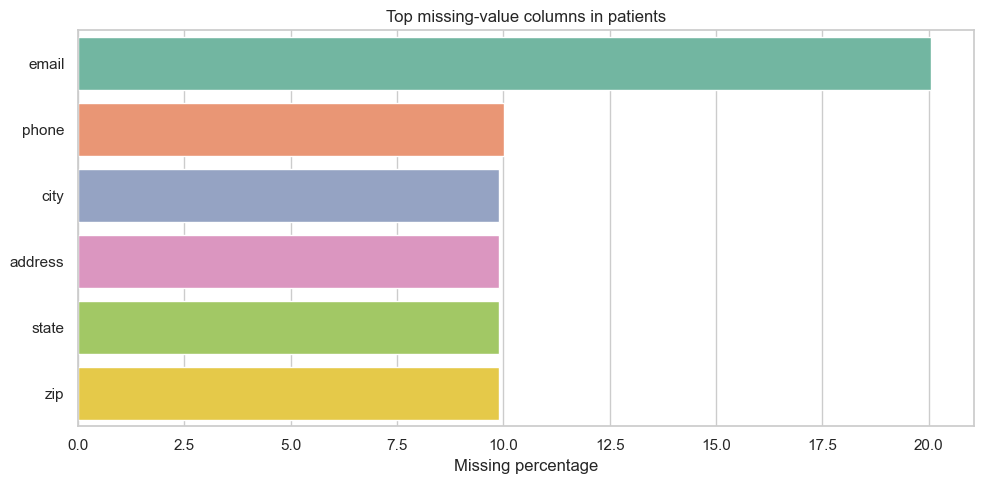

/var/folders/qs/d8f7sd3x6gl1p_s9hz43snjh0000gn/T/ipykernel_72400/3092849505.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_missing, x="missing_pct", y="column", palette="Set2")


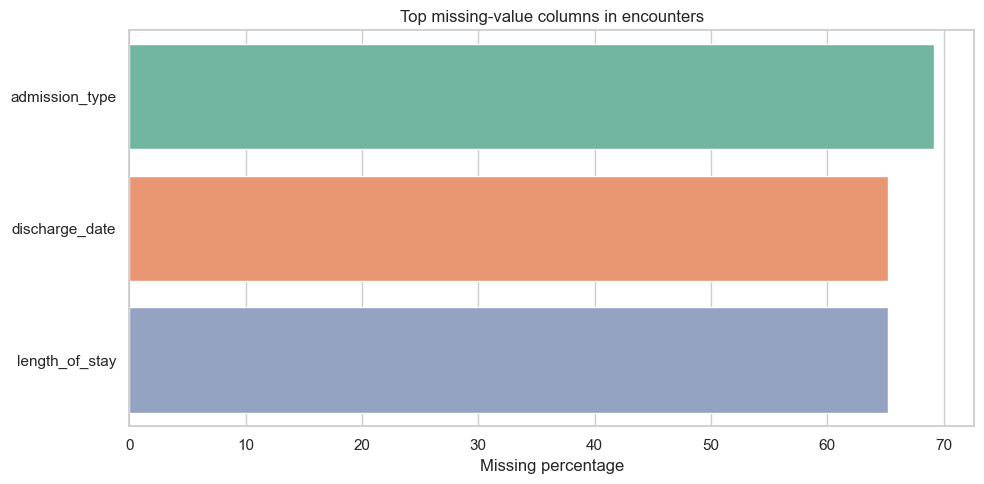

/var/folders/qs/d8f7sd3x6gl1p_s9hz43snjh0000gn/T/ipykernel_72400/3092849505.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_missing, x="missing_pct", y="column", palette="Set2")


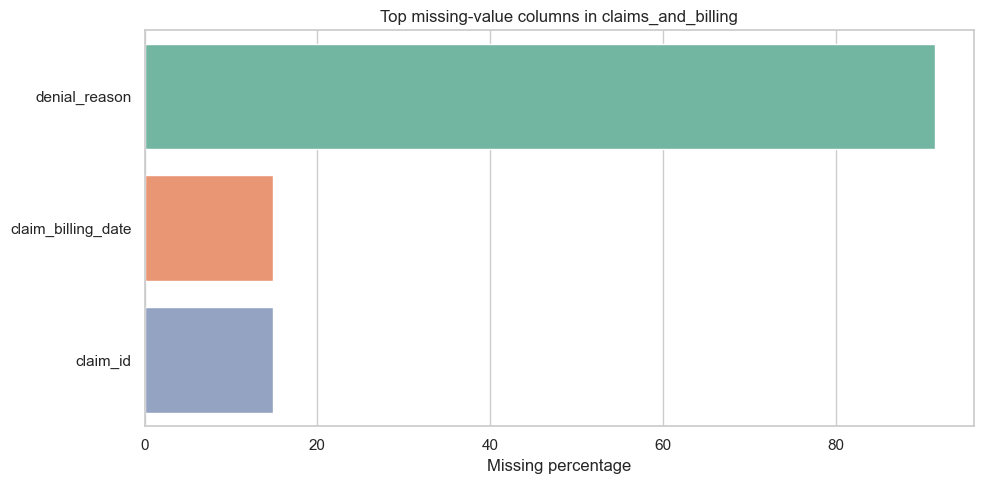

In [27]:
# Missing value charts
for dataset_name, missing_df in [
    ("patients", missing_patients),
    ("encounters", missing_encounters),
    ("claims_and_billing", missing_claims)
]:
    top_missing = missing_df[missing_df["missing_count"] > 0]

    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_missing, x="missing_pct", y="column", palette="Set2")
    plt.title(f"Top missing-value columns in {dataset_name}")
    plt.xlabel("Missing percentage")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

In [18]:
# Duplicate checks
print("patients full-row duplicates:", patients.duplicated().sum())
print("encounters full-row duplicates:", encounters.duplicated().sum())
print("claims full-row duplicates:", claims.duplicated().sum())

patients full-row duplicates: 0
encounters full-row duplicates: 0
claims full-row duplicates: 0


In [ ]:
# Checks for unique values in id fileds
key_checks = {
    "patients.patient_id": patients["patient_id"].nunique(),
    "encounters.encounter_id": encounters["encounter_id"].nunique(),
    "encounters.patient_id": encounters["patient_id"].nunique(),
    "claims.billing_id": claims["billing_id"].nunique(),
    "claims.claim_id": claims["claim_id"].nunique(dropna=True),
    "claims.encounter_id": claims["encounter_id"].nunique(),
    "claims.patient_id": claims["patient_id"].nunique()
}

pd.DataFrame(
    [{"field": k, "unique_values": v} for k, v in key_checks.items()]
)

,field,unique_values
0,patients.patient_id,60000
1,encounters.encounter_id,70000
2,encounters.patient_id,60000
3,claims.billing_id,70000
4,claims.claim_id,59638
5,claims.encounter_id,70000
6,claims.patient_id,60000


Datatypes transformation
Patients:
- dob, registration_date -> str to date
- zip -> Str to Int

Encounters
- visit_date, discharge_date -> str to date

Claims
- claim_billing_date -> str to date



In [20]:
patients["dob"] = pd.to_datetime(patients["dob"], errors="coerce")
patients["registration_date"] = pd.to_datetime(patients["registration_date"], errors="coerce")

encounters["visit_date"] = pd.to_datetime(encounters["visit_date"], errors="coerce")
encounters["discharge_date"] = pd.to_datetime(encounters["discharge_date"], errors="coerce")

claims["claim_billing_date"] = pd.to_datetime(claims["claim_billing_date"], errors="coerce")

# zip is an identifier, not a number
patients["zip"] = patients["zip"].astype("Int64").astype(str).replace("<NA>", np.nan)

print(patients.dtypes)
print(encounters.dtypes)
print(claims.dtypes)

/var/folders/qs/d8f7sd3x6gl1p_s9hz43snjh0000gn/T/ipykernel_72400/3181476907.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  patients["dob"] = pd.to_datetime(patients["dob"], errors="coerce")


patient_id                      str
first_name                      str
last_name                       str
dob                  datetime64[us]
age                           int64
gender                          str
ethnicity                       str
insurance_type                  str
marital_status                  str
address                         str
city                            str
state                           str
zip                             str
phone                           str
email                           str
registration_date    datetime64[us]
dtype: object
encounter_id                   str
patient_id                     str
provider_id                    str
visit_date          datetime64[us]
visit_type                     str
department                     str
reason_for_visit               str
diagnosis_code                 str
admission_type                 str
discharge_date      datetime64[us]
length_of_stay             float64
status                   

In [ ]:
# FK consistency check
enc_patient_match = encounters["patient_id"].isin(patients["patient_id"]).mean() * 100
claims_patient_match = claims["patient_id"].isin(patients["patient_id"]).mean() * 100
claims_encounter_match = claims["encounter_id"].isin(encounters["encounter_id"]).mean() * 100

referential_report = pd.DataFrame([
    {"relationship": "encounters.patient_id -> patients.patient_id", "match_pct": round(enc_patient_match, 2)},
    {"relationship": "claims.patient_id -> patients.patient_id", "match_pct": round(claims_patient_match, 2)},
    {"relationship": "claims.encounter_id -> encounters.encounter_id", "match_pct": round(claims_encounter_match, 2)}
])

display(referential_report)

,relationship,match_pct
0,encounters.patient_id -> patients.patient_id,100.0
1,claims.patient_id -> patients.patient_id,100.0
2,claims.encounter_id -> encounters.encounter_id,100.0


In [ ]:
# Check for orphan rows
orphan_claim_patients = claims.loc[~claims["patient_id"].isin(patients["patient_id"]), ["billing_id", "patient_id"]].head(10)
orphan_claim_encounters = claims.loc[~claims["encounter_id"].isin(encounters["encounter_id"]), ["billing_id", "encounter_id"]].head(10)
orphan_encounter_patients = encounters.loc[~encounters["patient_id"].isin(patients["patient_id"]), ["encounter_id", "patient_id"]].head(10)

display(orphan_claim_patients)
display(orphan_claim_encounters)
display(orphan_encounter_patients)

,billing_id,patient_id


,billing_id,encounter_id


,encounter_id,patient_id


Descriptive statistics on numeric data

In [23]:
print("PATIENTS numeric stats")
display(patients[["age"]].describe().T)

print("ENCOUNTERS numeric stats")
display(encounters[["length_of_stay"]].describe().T)

print("CLAIMS numeric stats")
display(claims[["billed_amount", "paid_amount"]].describe().T)

PATIENTS numeric stats


,count,mean,std,min,25%,50%,75%,max
age,60000.0,46.9878,25.138112,4.0,25.0,47.0,69.0,90.0


ENCOUNTERS numeric stats


,count,mean,std,min,25%,50%,75%,max
length_of_stay,24345.0,2.499569,0.50001,2.0,2.0,2.0,3.0,3.0


CLAIMS numeric stats


,count,mean,std,min,25%,50%,75%,max
billed_amount,70000.0,1612.866283,2047.355083,100.07,697.0475,1214.110,2090.125,38191.35
paid_amount,70000.0,1040.652151,1478.713641,0.00,366.5725,755.785,1357.895,38191.35


Financial relations - billed / paid / unpaid amount

In [24]:
claims["unpaid_amount"] = claims["billed_amount"] - claims["paid_amount"]

display(claims[["billed_amount", "paid_amount", "unpaid_amount"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
billed_amount,70000.0,1612.866283,2047.355083,100.07,697.0475,1214.110,2090.1250,38191.35
paid_amount,70000.0,1040.652151,1478.713641,0.00,366.5725,755.785,1357.8950,38191.35
unpaid_amount,70000.0,572.214133,946.724766,0.00,139.8875,365.360,716.1875,35956.07


Categorical distribution

In [25]:
def show_top_values(df, columns, dataset_name, top_n=10):
    for col in columns:
        print(f"\n{dataset_name} - {col}")
        display(df[col].value_counts(dropna=False).head(top_n))

show_top_values(patients, ["gender", "ethnicity", "insurance_type", "marital_status", "state"], "patients")
show_top_values(encounters, ["visit_type", "department", "admission_type", "status", "readmitted_flag"], "encounters")
show_top_values(claims, ["insurance_provider", "payment_method", "claim_status", "denial_reason"], "claims")


patients - gender


gender
Female    36036
Male      23964
Name: count, dtype: int64


patients - ethnicity


ethnicity
Hispanic    23873
White       21670
Asian       14457
Name: count, dtype: int64


patients - insurance_type


...

payment_method
Insurance    59638
Selfpay      10362
Name: count, dtype: int64


claims - claim_status


claim_status
Paid      64002
Denied     5998
Name: count, dtype: int64


claims - denial_reason


denial_reason
NaN                               64002
Duplicate Claim                     472
Prior Authorization Required        457
Service Not Covered                 437
Timely Filing Limit Exceeded        437
Coordination of Benefits Issue      436
Expired or Invalid Insurance        435
Coverage Limit Exceeded             432
Out-of-Network Provider             425
Claim Billed to Wrong Payer         422
Name: count, dtype: int64

## CHARTS
Dataset sizes

/var/folders/qs/d8f7sd3x6gl1p_s9hz43snjh0000gn/T/ipykernel_72400/3735840366.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_counts, x="dataset", y="rows", palette="Set2")


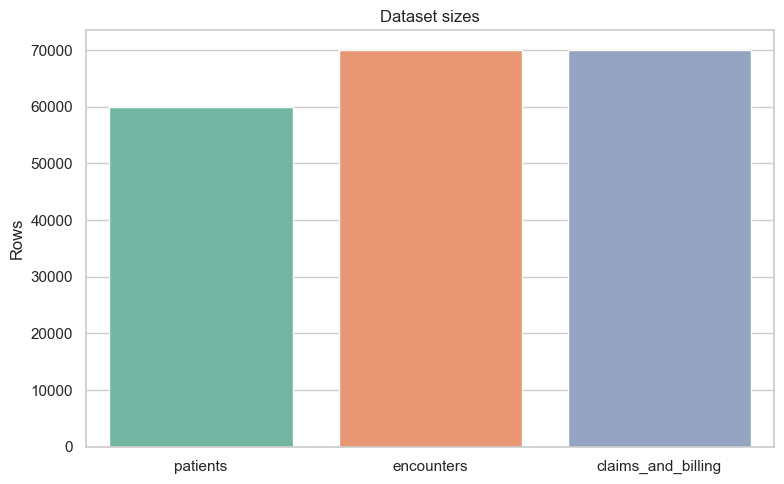

In [26]:
plt.figure(figsize=(8, 5))
sns.barplot(data=summary_counts, x="dataset", y="rows", palette="Set2")
plt.title("Dataset sizes")
plt.ylabel("Rows")
plt.xlabel("")
plt.tight_layout()
plt.show()

Patient age distribution

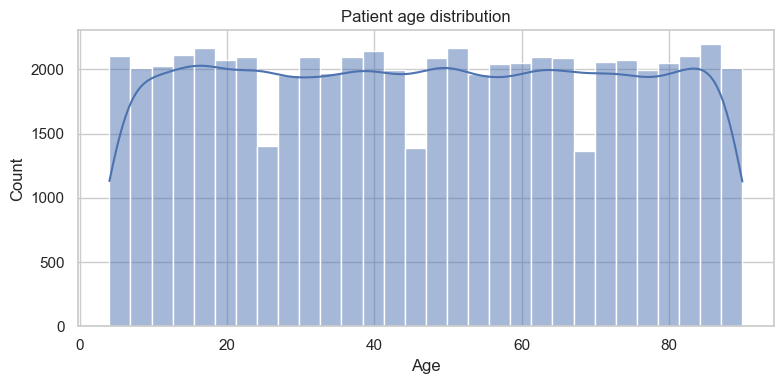

In [28]:
plt.figure(figsize=(8, 4))
sns.histplot(patients["age"], bins=30, kde=True)
plt.title("Patient age distribution")
plt.xlabel("Age")
plt.tight_layout()
plt.show()

Billed VS paid amount

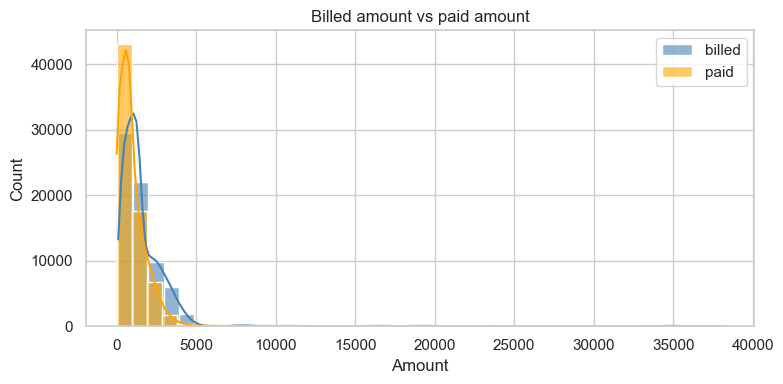

In [29]:
plt.figure(figsize=(8, 4))
sns.histplot(claims["billed_amount"], bins=40, color="steelblue", kde=True, label="billed", alpha=0.6)
sns.histplot(claims["paid_amount"], bins=40, color="orange", kde=True, label="paid", alpha=0.6)
plt.title("Billed amount vs paid amount")
plt.xlabel("Amount")
plt.legend()
plt.tight_layout()
plt.show()

Claim status chart

/var/folders/qs/d8f7sd3x6gl1p_s9hz43snjh0000gn/T/ipykernel_72400/3940382942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette="viridis")


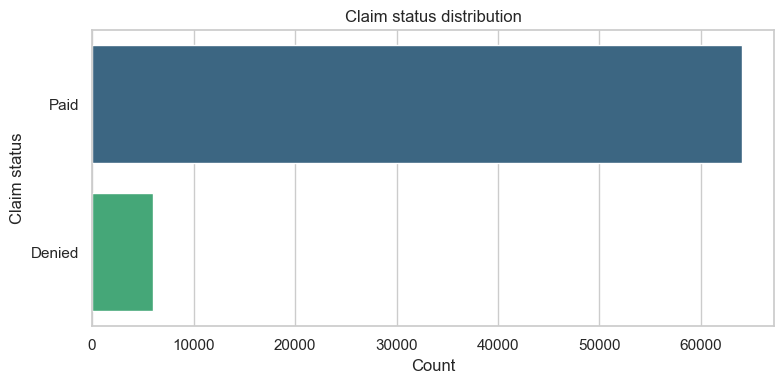

In [30]:
plt.figure(figsize=(8, 4))
vc = claims["claim_status"].value_counts()
sns.barplot(x=vc.values, y=vc.index, palette="viridis")
plt.title("Claim status distribution")
plt.xlabel("Count")
plt.ylabel("Claim status")
plt.tight_layout()
plt.show()

Visit type + Department

/var/folders/qs/d8f7sd3x6gl1p_s9hz43snjh0000gn/T/ipykernel_72400/1177329076.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette="crest")


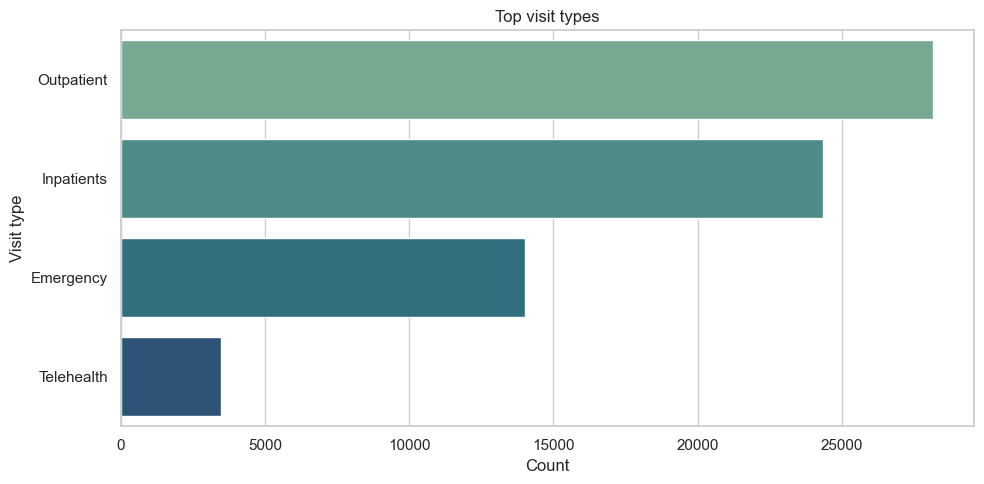

/var/folders/qs/d8f7sd3x6gl1p_s9hz43snjh0000gn/T/ipykernel_72400/1177329076.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette="mako")


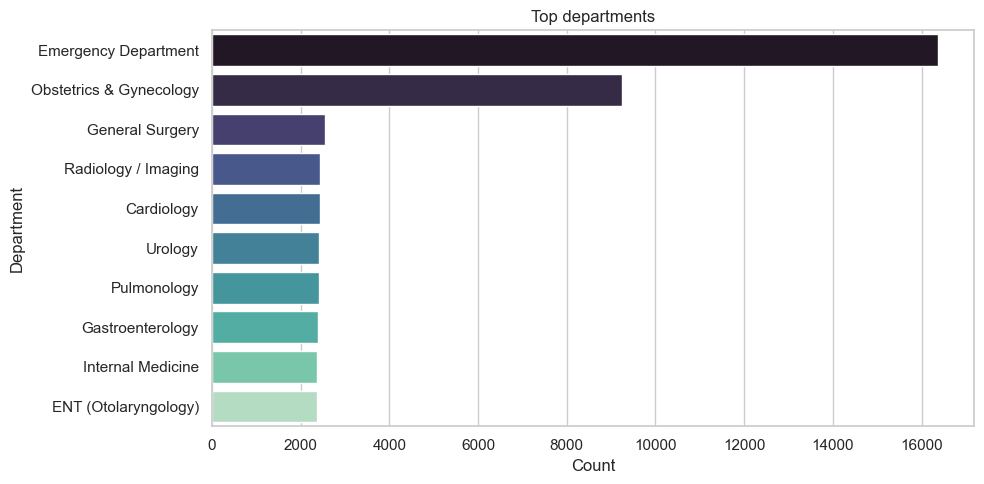

In [32]:
plt.figure(figsize=(10, 5))
vc = encounters["visit_type"].value_counts().head(10)
sns.barplot(x=vc.values, y=vc.index, palette="crest")
plt.title("Top visit types")
plt.xlabel("Count")
plt.ylabel("Visit type")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
vc = encounters["department"].value_counts().head(10)
sns.barplot(x=vc.values, y=vc.index, palette="mako")
plt.title("Top departments")
plt.xlabel("Count")
plt.ylabel("Department")
plt.tight_layout()
plt.show()

Monthly trend

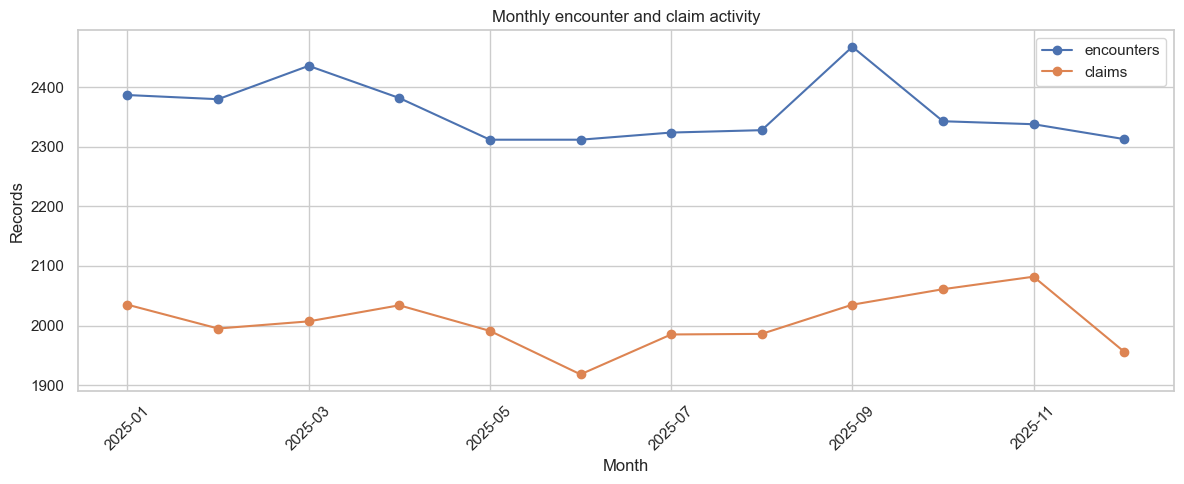

In [33]:
encounters["visit_month"] = encounters["visit_date"].dt.to_period("M").astype(str)
claims["claim_month"] = claims["claim_billing_date"].dt.to_period("M").astype(str)

enc_monthly = encounters["visit_month"].value_counts().sort_index()
claim_monthly = claims["claim_month"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
enc_monthly.plot(marker="o", label="encounters")
claim_monthly.plot(marker="o", label="claims")
plt.title("Monthly encounter and claim activity")
plt.xlabel("Month")
plt.ylabel("Records")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Readmission analysis

In [34]:
readmission_summary = encounters.groupby("readmitted_flag").agg(
    encounters_count=("encounter_id", "count"),
    avg_length_of_stay=("length_of_stay", "mean")
).reset_index()

display(readmission_summary)

,readmitted_flag,encounters_count,avg_length_of_stay
0,No,59003,2.498642
1,Yes,10997,2.503313


Financial report on claims

In [35]:
claim_status_summary = claims.groupby("claim_status").agg(
    total_billed=("billed_amount", "sum"),
    total_paid=("paid_amount", "sum"),
    avg_unpaid=("unpaid_amount", "mean"),
    count=("billing_id", "count")
).reset_index().sort_values("total_billed", ascending=False)

display(claim_status_summary)

,claim_status,total_billed,total_paid,avg_unpaid,count
1,Paid,1.032549e+08,72845650.54,475.129042,64002
0,Denied,9.645780e+06,0.00,1608.166110,5998


### Data cleaning

Check forr whitespaces in id fields

In [41]:
# Check whether any ID fields originally contained leading/trailing whitespace

def whitespace_issue_count(df, columns):
    results = []
    for col in columns:
        if col in df.columns:
            s = df[col].dropna().astype(str)
            count = (s != s.str.strip()).sum()
            results.append({"column": col, "rows_with_whitespace": int(count)})
    return pd.DataFrame(results)

print("PATIENTS whitespace issues")
display(whitespace_issue_count(patients, ["patient_id"]))

print("ENCOUNTERS whitespace issues")
display(whitespace_issue_count(encounters, ["encounter_id", "patient_id", "provider_id"]))

print("CLAIMS whitespace issues")
display(whitespace_issue_count(claims, ["billing_id", "patient_id", "encounter_id", "claim_id"]))

PATIENTS whitespace issues


,column,rows_with_whitespace
0,patient_id,0


ENCOUNTERS whitespace issues


,column,rows_with_whitespace
0,encounter_id,0
1,patient_id,0
2,provider_id,0


CLAIMS whitespace issues


,column,rows_with_whitespace
0,billing_id,0
1,patient_id,0
2,encounter_id,0
3,claim_id,0
